# 한국어-영어 번역기 프로젝트 

In [1]:
# konlpy:
#   한국어 형태소 분석기를 사용하기 위한 패키지
# python-mecab-ko:
#   konlpy의 Mecab이 환경 문제로 작동하지 않을 때를 대비한 대체 Mecab 패키지

!pip install konlpy
!pip install python-mecab-ko


In [2]:
# ==============================
# 1. 라이브러리 불러오기
# ==============================

# os:
#   폴더 생성, 파일 경로 처리에 사용
import os

# re:
#   정규표현식을 사용해 문장에서 불필요한 문자 제거, 구두점 처리
import re

# tarfile:
#   tar.gz 압축 파일을 해제하기 위해 사용
import tarfile

# urllib.request:
#   URL에서 데이터를 다운로드할 때 사용
import urllib.request

# Counter:
#   단어 빈도를 세어 vocab을 만들 때 사용
from collections import Counter

# numpy:
#   attention map 시각화 등 배열 처리를 위해 사용
import numpy as np

# pandas:
#   이번 코드에서는 필수는 아니지만 데이터 확인이나 표 형태 정리에 유용
import pandas as pd

# matplotlib:
#   Attention Map을 시각화할 때 사용
import matplotlib.pyplot as plt

# torch:
#   PyTorch 기본 라이브러리
import torch

# torch.nn:
#   Embedding, GRU, Linear, Loss 등 딥러닝 모델 구성 요소가 들어 있음
import torch.nn as nn

# torch.optim:
#   Adam 같은 optimizer를 사용하기 위해 필요
import torch.optim as optim

# Dataset, DataLoader:
#   데이터를 배치 단위로 모델에 넣기 위해 사용
from torch.utils.data import Dataset, DataLoader

# GPU가 있으면 cuda를 사용하고, 없으면 cpu를 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("device:", device)


PyTorch version: 2.7.1+cu118
device: cuda


In [3]:
# ==============================
# 2. Mecab 형태소 분석기 준비
# ==============================

class SimpleKoreanTokenizer:
    def morphs(self, sentence):
        # Mecab이 모두 실패했을 때만 사용하는 임시 대체 토크나이저입니다.
        # 과제 조건을 엄밀히 만족하려면 Mecab을 사용하는 것이 좋습니다.
        tokens = sentence.split()
        if len(tokens) <= 1:
            return list(sentence.replace(" ", ""))
        return tokens


try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    print("konlpy Mecab 사용")
except Exception as e1:
    print("konlpy Mecab 실패:", e1)

    try:
        from mecab import MeCab
        _mecab_ko = MeCab()

        class MecabKoWrapper:
            def morphs(self, sentence):
                return _mecab_ko.morphs(sentence)

        mecab = MecabKoWrapper()
        print("python-mecab-ko 사용")
    except Exception as e2:
        print("python-mecab-ko 실패:", e2)

    
        mecab = SimpleKoreanTokenizer()
        print("임시 SimpleKoreanTokenizer 사용")

# Mecab이 잘 작동하는지 확인합니다.
print(mecab.morphs("오바마는 대통령이다."))


konlpy Mecab 실패: Install MeCab in order to use it: http://konlpy.org/en/latest/install/
python-mecab-ko 사용
['오바마', '는', '대통령', '이', '다', '.']


# Step 1. 데이터 다운로드

과제에서 지정한 `korean-english-park.train.tar.gz` 파일을 다운로드
압축을 풀면 한국어 문장 파일 `.ko`와 영어 문장 파일 `.en`이 따로 존재


In [4]:
# ==============================
# 3. 데이터 다운로드 및 압축 해제
# ==============================

# 데이터를 저장할 폴더를 지정
data_dir = "./korean_english_data"

# 폴더가 없으면 새로 만읆
os.makedirs(data_dir, exist_ok=True)

url = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"

# 다운로드한 tar.gz 파일을 저장할 경로
tar_path = os.path.join(data_dir, "korean-english-park.train.tar.gz")

# 이미 다운로드한 파일이 없을 때만 다운로드
# 이렇게 하면 같은 셀을 여러 번 실행해도 불필요하게 다시 다운로드하지 않음
if not os.path.exists(tar_path):
    urllib.request.urlretrieve(url, tar_path)
    print("데이터 다운로드 완료")
else:
    print("이미 데이터가 존재합니다.")

# tar.gz 압축 파일을 풀기
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=data_dir)

print("압축 해제 완료")

# 압축 해제 후 어떤 파일이 생겼는지 확인
# 여기에서 .ko, .en 파일이 보이면 정상
for root, dirs, files in os.walk(data_dir):
    for file in files:
        print(os.path.join(root, file))


이미 데이터가 존재합니다.


/tmp/ipykernel_425/1707994043.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=data_dir)


압축 해제 완료
./korean_english_data/korean-english-park.train.tar.gz
./korean_english_data/korean-english-park.train.ko
./korean_english_data/korean-english-park.train.en


In [5]:
# ==============================
# 4. 한국어 파일과 영어 파일 찾기
# ==============================
# 압축을 풀면 korean-english-park.train.ko,
# korean-english-park.train.en 같은 파일이 생성
#
# 환경에 따라 압축 해제 위치가 달라질 수 있으므로
# os.walk로 하위 폴더까지 탐색하여 .ko, .en 파일을 찾기

kor_path = None
eng_path = None

for root, dirs, files in os.walk(data_dir):
    for file in files:
        # 한국어 파일
        if file.endswith(".ko"):
            kor_path = os.path.join(root, file)

        # 영어 파일
        elif file.endswith(".en"):
            eng_path = os.path.join(root, file)

print("한국어 파일:", kor_path)
print("영어 파일:", eng_path)

# 파일을 찾지 못하면 이후 코드가 정상 실행될 수 없으므로 assert로 확인
assert kor_path is not None, "한국어 .ko 파일을 찾지 못했습니다."
assert eng_path is not None, "영어 .en 파일을 찾지 못했습니다."


한국어 파일: ./korean_english_data/korean-english-park.train.ko
영어 파일: ./korean_english_data/korean-english-park.train.en


In [6]:
# ==============================
# 5. 한국어-영어 병렬 데이터 읽기
# ==============================

# 한국어 문장 파일을 한 줄씩 읽어 리스트로 저장
with open(kor_path, "r", encoding="utf-8") as f:
    kor_raw = f.read().splitlines()

# 영어 문장 파일도 한 줄씩 읽어 리스트로 저장
with open(eng_path, "r", encoding="utf-8") as f:
    eng_raw = f.read().splitlines()

print("한국어 문장 수:", len(kor_raw))
print("영어 문장 수:", len(eng_raw))

# 병렬 데이터이므로 한국어와 영어 문장 개수가 같아야 함
# 예를 들어 kor_raw[0]은 eng_raw[0]의 번역문이어야 함
assert len(kor_raw) == len(eng_raw), "한국어와 영어 문장 수가 다릅니다."

print("\n[한국어 예시]")
print(kor_raw[0])

print("\n[영어 예시]")
print(eng_raw[0])


한국어 문장 수: 94123
영어 문장 수: 94123

[한국어 예시]
개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"

[영어 예시]
Much of personal computing is about "can you top this?"


# Step 2. 데이터 정제

중복 제거는 반드시 **문장 쌍 단위**로 해야 하며, 
한국어만 따로 중복 제거하거나 영어만 따로 중복 제거하면 서로의 번역 관계가 깨질 수 있다.


In [7]:
# ==============================
# 6. 중복 제거
# ==============================
#   set 데이터형이 중복을 허용하지 않는다는 것을 활용해 중복된 데이터를 제거
#   병렬 쌍이 흐트러지지 않게 주의
#
# zip(kor_raw, eng_raw):
#   한국어 문장과 영어 문장을 같은 인덱스끼리 묶기.
#
# 예:
#   ("오바마는 대통령이다.", "obama is the president.")
#
# set(...):
#   같은 문장 쌍이 여러 번 있으면 하나만 남김.
#
# list(...):
#   이후 반복문에서 사용하기 위해 다시 리스트로 변환

cleaned_corpus = list(set(zip(kor_raw, eng_raw)))

print("중복 제거 전 문장 쌍 개수:", len(kor_raw))
print("중복 제거 후 문장 쌍 개수:", len(cleaned_corpus))

print("\n[중복 제거 후 예시]")
print(cleaned_corpus[0])


중복 제거 전 문장 쌍 개수: 94123
중복 제거 후 문장 쌍 개수: 78968

[중복 제거 후 예시]
('올해 34세인 하산우딘은 자카르타 법원에서 자신은 참수를 도왔지만, 주모자로 이를 지휘했다는 혐의는 부인했다.', 'Hasanuddin, who is 34, told a Jakarta court he helped plan the attack but he rejected allegations he masterminded it.')


In [8]:
# ==============================
# 7. preprocessing 함수 재정의
# ==============================
# 정규식에 '가-힣' 범위를 추가합니다.
#
# 처리 내용:
# 1. 앞뒤 공백 제거
# 2. 영어 소문자 변환
# 3. 구두점 앞뒤 공백 추가
# 4. 한글, 영어, 기본 구두점만 남김
# 5. 여러 공백을 하나로 정리

def preprocessing(sentence):
    # 앞뒤 공백 제거
    sentence = sentence.strip()

    # 영어 문장을 소문자로 통일
    # 한국어에는 큰 영향이 없다.
    sentence = sentence.lower()

    # 구두점 앞뒤에 공백을 추가
    # 예: "president." -> "president ."
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 한글, 영어, 기본 구두점만 남김
    # 여기에서 '가-힣'을 넣어야 한국어가 삭제되지 않음
    sentence = re.sub(r"[^가-힣a-zA-Z?.!,]+", " ", sentence)

    # 여러 개의 공백을 하나로 줄임
    sentence = re.sub(r"\s+", " ", sentence)

    # 마지막으로 앞뒤 공백을 다시 제거
    sentence = sentence.strip()

    return sentence

print(preprocessing("오바마는 대통령이다."))
print(preprocessing("Obama is the president."))


오바마는 대통령이다 .
obama is the president .


In [9]:
# ==============================
# 8. kor_corpus, eng_corpus 구축
# ==============================
#   - 한국어 토큰화는 Mecab 사용
#   - 영어 타겟 문장에는 <start>, <end> 추가
#   - 영어는 split()으로 토큰화
#   - 토큰 길이 40 이하 문장만 사용
#
# kor_corpus:
#   모델의 Encoder 입력으로 들어갈 한국어 토큰 리스트
#
# eng_corpus:
#   모델의 Decoder 입력/정답으로 사용될 영어 토큰 리스트

MAX_LEN = 40

kor_corpus = []
eng_corpus = []

for kor, eng in cleaned_corpus:
    # 한국어와 영어 문장을 각각 전처리
    kor = preprocessing(kor)
    eng = preprocessing(eng)

    # 전처리 후 빈 문장이 된 경우는 제외
    if len(kor) == 0 or len(eng) == 0:
        continue

    # 한국어는 Mecab으로 형태소 단위 토큰화
    # 예: "오바마는 대통령이다." -> ['오바마', '는', '대통령', '이', '다', '.']
    kor_tokens = mecab.morphs(kor)

    # 영어는 타겟 언어이므로 시작 토큰과 종료 토큰을 추가
    # Decoder는 <start>를 보고 첫 단어 생성을 시작하고,
    # <end>를 생성하면 문장 생성을 멈춤
    eng_sentence = "<start> " + eng + " <end>"

    # 영어는 split()으로 공백 기준 토큰화
    eng_tokens = eng_sentence.split()

    # 너무 긴 문장은 학습 시간이 오래 걸리고 성능을 떨어뜨릴 수 있으므로
    # 토큰 길이 40 이하 문장만 사용
    if len(kor_tokens) <= MAX_LEN and len(eng_tokens) <= MAX_LEN:
        kor_corpus.append(kor_tokens)
        eng_corpus.append(eng_tokens)

print("최종 한국어 코퍼스 개수:", len(kor_corpus))
print("최종 영어 코퍼스 개수:", len(eng_corpus))

print("\n[한국어 토큰 예시]")
print(kor_corpus[0])

print("\n[영어 토큰 예시]")
print(eng_corpus[0])


최종 한국어 코퍼스 개수: 62738
최종 영어 코퍼스 개수: 62738

[한국어 토큰 예시]
['올해', '세인', '하산', '우딘', '은', '자카르타', '법원', '에서', '자신', '은', '참수', '를', '도왔', '지만', ',', '주모자', '로', '이', '를', '지휘', '했', '다는', '혐의', '는', '부인', '했', '다', '.']

[영어 토큰 예시]
['<start>', 'hasanuddin', ',', 'who', 'is', ',', 'told', 'a', 'jakarta', 'court', 'he', 'helped', 'plan', 'the', 'attack', 'but', 'he', 'rejected', 'allegations', 'he', 'masterminded', 'it', '.', '<end>']


# Step 3. 데이터 토큰화

`tokenize()` 함수를 사용해 문장을 숫자 텐서로 변환
단어 사전 크기는 과제 조건에 맞게 10,000 이상으로 설정


In [10]:
# ==============================
# 9. 단어 사전 생성 함수
# ==============================
# 딥러닝 모델은 문자열을 직접 학습할 수 없음
# 따라서 각 토큰을 숫자 id로 바꿔야 함
#
# 예:
#   "오바마" -> 45
#   "대통령" -> 123
#
# build_vocab()은 토큰화된 corpus를 받아
# word2idx, idx2word를 만듦
#
# word2idx:
#   단어를 숫자로 바꾸는 딕셔너리
#
# idx2word:
#   숫자를 단어로 되돌리는 딕셔너리

PAD_TOKEN = "<pad>"   # padding 토큰
UNK_TOKEN = "<unk>"   # 사전에 없는 단어 토큰

def build_vocab(tokenized_corpus, vocab_size=12000, specials=None):
    # special token을 지정하지 않으면 기본적으로 pad와 unk를 사용
    if specials is None:
        specials = [PAD_TOKEN, UNK_TOKEN]

    # Counter는 각 단어가 몇 번 나왔는지 세어줌
    counter = Counter()

    for tokens in tokenized_corpus:
        counter.update(tokens)

    word2idx = {}
    idx2word = {}

    # special token을 먼저 vocab에 넣기
    # <pad>는 0번이 되도록 가장 먼저 넣기
    for token in specials:
        idx = len(word2idx)
        word2idx[token] = idx
        idx2word[idx] = token

    # 많이 등장한 단어부터 vocab에 추가
    # vocab_size보다 많은 단어는 제외
    for word, count in counter.most_common(vocab_size - len(word2idx)):
        if word not in word2idx:
            idx = len(word2idx)
            word2idx[word] = idx
            idx2word[idx] = word

    return word2idx, idx2word


In [11]:
# ==============================
# 10. tokenize 함수
# ==============================
# tokenize()는 토큰 리스트를 숫자 id 리스트로 바꾼 뒤
# 길이를 MAX_LEN으로 맞추어 텐서로 변환
#
# 길이가 MAX_LEN보다 짧으면 <pad>를 뒤에 붙이고,
# 길이가 MAX_LEN보다 길면 앞에서부터 MAX_LEN까지만 사용

def tokenize(tokenized_corpus, word2idx, max_len=40):
    tensor = []

    for tokens in tokenized_corpus:
        # 각 토큰을 숫자 id로 변환
        # vocab에 없는 단어는 <unk> id로 처리
        ids = [word2idx.get(token, word2idx[UNK_TOKEN])for token in tokens]

        # 너무 긴 문장은 max_len까지만 자름
        ids = ids[:max_len]

        # 짧은 문장은 뒤쪽에 <pad>를 추가하여 길이를 맞춤
        ids += [word2idx[PAD_TOKEN]] * (max_len - len(ids))

        tensor.append(ids)

    return torch.tensor(tensor, dtype=torch.long)


In [12]:
# ==============================
# 11. vocab 생성 및 텐서 변환
# ==============================
# 단어 수는 최소 10,000 이상이어야 함

VOCAB_SIZE = 12000

# 한국어 단어 사전 생성
# 한국어는 Encoder 입력이므로 <pad>, <unk>만 special token으로 둠
kor_word2idx, kor_idx2word = build_vocab(kor_corpus,vocab_size=VOCAB_SIZE,specials=[PAD_TOKEN, UNK_TOKEN])

# 영어 단어 사전 생성
# 영어는 Decoder가 생성할 문장이므로 <start>, <end>가 꼭 필요
eng_word2idx, eng_idx2word = build_vocab(eng_corpus,vocab_size=VOCAB_SIZE,specials=[PAD_TOKEN, UNK_TOKEN, "<start>", "<end>"])

# 한국어 corpus를 Encoder 입력 텐서로 변환
enc_tensor = tokenize(kor_corpus, kor_word2idx, MAX_LEN)

# 영어 corpus를 Decoder용 텐서로 변환
dec_tensor = tokenize(eng_corpus, eng_word2idx, MAX_LEN)

print("Encoder tensor shape:", enc_tensor.shape)
print("Decoder tensor shape:", dec_tensor.shape)
print("한국어 vocab size:", len(kor_word2idx))
print("영어 vocab size:", len(eng_word2idx))
print("<start> id:", eng_word2idx["<start>"])
print("<end> id:", eng_word2idx["<end>"])


Encoder tensor shape: torch.Size([62738, 40])
Decoder tensor shape: torch.Size([62738, 40])
한국어 vocab size: 12000
영어 vocab size: 11998
<start> id: 2
<end> id: 3


In [13]:
# ==============================
# 12. Decoder 입력과 정답 만들기
# ==============================
# Decoder 학습 방식:
#
# 전체 영어 문장:
#   <start> obama is the president . <end>
#
# Decoder 입력:
#   <start> obama is the president .
#
# Decoder 정답:
#   obama is the president . <end>
#
# 즉, Decoder는 이전 단어를 보고 다음 단어를 예측하도록 학습

dec_input = dec_tensor[:, :-1]
dec_target = dec_tensor[:, 1:]

print("Encoder 입력:", enc_tensor.shape)
print("Decoder 입력:", dec_input.shape)
print("Decoder 정답:", dec_target.shape)


Encoder 입력: torch.Size([62738, 40])
Decoder 입력: torch.Size([62738, 39])
Decoder 정답: torch.Size([62738, 39])


In [14]:
# ==============================
# 13. Dataset과 DataLoader 생성
# ==============================
# 전체 데이터를 하나의 학습 데이터셋으로 사용

BATCH_SIZE = 64

class TranslationDataset(Dataset):
    def __init__(self, enc_tensor, dec_input, dec_target):
        # Encoder 입력 데이터
        self.enc_tensor = enc_tensor

        # Decoder 입력 데이터
        self.dec_input = dec_input

        # Decoder 정답 데이터
        self.dec_target = dec_target

    def __len__(self):
        # 전체 데이터 개수 반환
        return len(self.enc_tensor)

    def __getitem__(self, idx):
        # idx번째 데이터를 반환
        return (self.enc_tensor[idx],self.dec_input[idx],self.dec_target[idx])

dataset = TranslationDataset(enc_tensor, dec_input, dec_target)

# DataLoader는 데이터를 batch 단위로 묶어 모델에 넣어줌
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 학습 안정성을 높임
data_loader = DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)

print("전체 데이터 수:", len(dataset))
print("배치 수:", len(data_loader))


전체 데이터 수: 62738
배치 수: 980


# Step 4. Attention 기반 Seq2Seq 모델 설계

번역 모델을 만들기

### 구조
1. Encoder가 한국어 문장을 읽음  
2. Attention이 입력 문장의 중요한 부분을 계산  
3. Decoder가 영어 문장을 한 단어씩 생성  


In [15]:
# ==============================
# 14. Bahdanau Attention
# ==============================
# Attention의 역할:
#   Decoder가 영어 단어를 하나 생성할 때,
#   Encoder가 읽은 한국어 문장 중 어느 부분을 더 참고할지 계산
#
# 예:
#   "오바마는 대통령이다."
#   -> "president"를 생성할 때는 "대통령"에 높은 attention을 줄 수 있다.

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        # Encoder output에 적용할 선형층
        self.W1 = nn.Linear(hidden_dim, hidden_dim)

        # Decoder hidden state에 적용할 선형층
        self.W2 = nn.Linear(hidden_dim, hidden_dim)

        # attention score를 하나의 값으로 바꾸는 선형층
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, hidden, encoder_outputs):
        # hidden:
        #   Decoder의 현재 hidden state
        #   shape: [batch, hidden_dim]
        #
        # encoder_outputs:
        #   Encoder의 모든 시점 output
        #   shape: [batch, src_len, hidden_dim]

        # hidden을 encoder_outputs와 더할 수 있도록 시간축을 추가
        # [batch, hidden_dim] -> [batch, 1, hidden_dim]
        hidden = hidden.unsqueeze(1)

        # Encoder output과 Decoder hidden을 비교하여 score 계산
        score = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(hidden)))

        # score를 확률처럼 해석하기 위해 softmax 적용
        # src_len 방향으로 합이 1
        attention_weights = torch.softmax(score, dim=1)

        # attention 가중치를 encoder_outputs에 곱
        # 중요한 입력 토큰의 정보가 더 크게 반영
        context = attention_weights * encoder_outputs

        # src_len 방향으로 합쳐 context vector 생성
        context = torch.sum(context, dim=1)

        return context, attention_weights


In [16]:
# ==============================
# 15. Encoder
# ==============================
# Encoder의 역할:
#   한국어 문장을 입력받아 문맥 정보를 hidden state로 변환
#
# 구성:
#   1. Embedding
#      단어 id를 dense vector로 변환
#
#   2. GRU
#      문장의 순서를 반영해 hidden state 생성

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, pad_idx):
        super().__init__()

        # input_dim:
        #   한국어 vocab 크기
        #
        # emb_dim:
        #   각 단어를 몇 차원 벡터로 표현할지 결정
        #
        # padding_idx:
        #   <pad> 토큰은 학습에 영향을 덜 주도록 지정
        self.embedding = nn.Embedding(input_dim,emb_dim,padding_idx=pad_idx)

        # GRU는 RNN 계열 모델로 문장 순서를 학습
        self.gru = nn.GRU(emb_dim,hidden_dim,batch_first=True)

    def forward(self, src):
        # src shape:
        #   [batch, src_len]

        # 단어 id를 embedding vector로 변환
        # [batch, src_len] -> [batch, src_len, emb_dim]
        embedded = self.embedding(src)

        # GRU 통과
        # outputs:
        #   모든 시점의 hidden state
        #   [batch, src_len, hidden_dim]
        #
        # hidden:
        #   마지막 시점 hidden state
        #   [1, batch, hidden_dim]
        outputs, hidden = self.gru(embedded)

        return outputs, hidden


In [17]:
# ==============================
# 16. Decoder
# ==============================
# Decoder의 역할:
#   Encoder와 Attention의 정보를 참고하여 영어 문장을 생성
#
# Decoder는 한 번에 전체 문장을 생성하는 것이 아니라
# 한 단어씩 순서대로 생성

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, pad_idx):
        super().__init__()

        # output_dim:
        #   영어 vocab 크기
        self.output_dim = output_dim

        # 영어 단어 id를 embedding vector로 변환
        self.embedding = nn.Embedding(output_dim,emb_dim,padding_idx=pad_idx)

        # Attention 모듈
        self.attention = BahdanauAttention(hidden_dim)

        # Decoder GRU 입력은
        # 현재 단어 embedding + attention context vector
        self.gru = nn.GRU(emb_dim + hidden_dim,hidden_dim,batch_first=True)

        # GRU output을 영어 vocab 크기의 점수로 변환
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden, encoder_outputs):
        # input_token:
        #   현재 Decoder 입력 단어
        #   shape: [batch]
        #
        # hidden:
        #   이전 Decoder hidden state
        #   shape: [1, batch, hidden_dim]
        #
        # encoder_outputs:
        #   Encoder의 모든 output
        #   shape: [batch, src_len, hidden_dim]

        # [batch] -> [batch, 1]
        input_token = input_token.unsqueeze(1)

        # 현재 입력 단어를 embedding으로 변환
        # [batch, 1] -> [batch, 1, emb_dim]
        embedded = self.embedding(input_token)

        # Attention 계산을 위해 hidden shape 변경
        # [1, batch, hidden_dim] -> [batch, hidden_dim]
        dec_hidden = hidden.squeeze(0)

        # Attention으로 context vector 계산
        context, attention_weights = self.attention(dec_hidden,encoder_outputs)

        # [batch, hidden_dim] -> [batch, 1, hidden_dim]
        context = context.unsqueeze(1)

        # 현재 단어 embedding과 context vector를 연결
        rnn_input = torch.cat([embedded, context], dim=2)

        # GRU 통과
        output, hidden = self.gru(rnn_input, hidden)

        # output을 vocab 크기만큼의 점수로 변환
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden, attention_weights


In [18]:
# ==============================
# 17. Seq2Seq Attention 모델
# ==============================
# Encoder와 Decoder를 하나로 연결
#
# 학습 과정:
#   1. Encoder가 한국어 문장을 읽음
#   2. Decoder가 <start>부터 시작
#   3. Teacher Forcing으로 실제 정답 토큰을 다음 입력으로 사용
#   4. 각 시점에서 다음 영어 단어를 예측

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg_input):
        # src:
        #   Encoder 입력 한국어 문장
        #   shape: [batch, src_len]
        #
        # trg_input:
        #   Decoder 입력 영어 문장
        #   shape: [batch, trg_len]

        batch_size = src.shape[0]
        trg_len = trg_input.shape[1]
        trg_vocab_size = self.decoder.output_dim

        # 모든 시점의 Decoder 출력을 저장할 빈 텐서 생성
        outputs = torch.zeros(batch_size,trg_len,trg_vocab_size).to(self.device)

        # Encoder 실행
        encoder_outputs, hidden = self.encoder(src)

        # Decoder 첫 입력은 <start> 토큰
        input_token = trg_input[:, 0]

        # t=1부터 시작하는 이유:
        # t=0은 <start> 자체이므로 예측 대상이 아님
        for t in range(1, trg_len):
            # Decoder가 다음 단어를 예측
            output, hidden, _ = self.decoder(input_token,hidden,encoder_outputs)

            # 예측 결과 저장
            outputs[:, t, :] = output

            # Teacher Forcing:
            # 모델이 예측한 단어가 아니라
            # 실제 정답 문장의 현재 토큰을 다음 입력으로 사용
            input_token = trg_input[:, t]

        return outputs


In [19]:
# ==============================
# 18. 모델 생성
# ==============================

# 입력 vocab 크기: 한국어 단어 사전 크기
INPUT_DIM = len(kor_word2idx)

# 출력 vocab 크기: 영어 단어 사전 크기
OUTPUT_DIM = len(eng_word2idx)

# embedding 차원
EMB_DIM = 256

# GRU hidden state 차원
HID_DIM = 512

# padding index
kor_pad_idx = kor_word2idx[PAD_TOKEN]
eng_pad_idx = eng_word2idx[PAD_TOKEN]

# Encoder 생성
encoder = Encoder(INPUT_DIM,EMB_DIM,HID_DIM,kor_pad_idx)

# Decoder 생성
decoder = Decoder(OUTPUT_DIM,EMB_DIM,HID_DIM,eng_pad_idx)

# Seq2Seq Attention 모델 생성
model = Seq2SeqAttention(encoder,decoder,device).to(device)

# optimizer:
#   모델 파라미터를 업데이트하는 알고리즘
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# loss 함수:
#   모델 예측과 실제 정답의 차이를 계산
#   padding 토큰은 loss 계산에서 제외
criterion = nn.CrossEntropyLoss(ignore_index=eng_pad_idx)

print(model)


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(12000, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(11998, 256, padding_idx=0)
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=1, bias=True)
    )
    (gru): GRU(768, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=11998, bias=True)
  )
)


# Step 5. 훈련하기
  
학습하면서 각 epoch마다 예문 4개의 번역 결과를 확인


In [20]:
# ==============================
# 19. train_step 함수
# ==============================
# 한 epoch 동안 전체 data_loader를 돌면서 모델을 학습
#
# 학습 과정:
#   1. 데이터를 GPU/CPU device로 이동
#   2. 모델 예측
#   3. loss 계산
#   4. 역전파
#   5. optimizer로 파라미터 업데이트

def train_step(model, data_loader, optimizer, criterion, epoch):
    # 모델을 학습 모드로 설정
    model.train()

    epoch_loss = 0

    for batch_idx, (src, trg_input, trg_label) in enumerate(data_loader):
        # 데이터를 device로 이동
        src = src.to(device)
        trg_input = trg_input.to(device)
        trg_label = trg_label.to(device)

        # 이전 batch에서 계산된 gradient를 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = model(src, trg_input)

        # outputs shape:
        #   [batch, trg_len, output_dim]
        #
        # trg_label shape:
        #   [batch, trg_len]
        output_dim = outputs.shape[-1]

        # 첫 토큰은 <start>이므로 loss 계산에서 제외
        outputs = outputs[:, 1:, :].reshape(-1, output_dim)
        trg_label = trg_label[:, 1:].reshape(-1)

        # 예측값과 정답 사이의 loss 계산
        loss = criterion(outputs, trg_label)

        # 역전파로 gradient 계산
        loss.backward()

        # RNN 계열 모델은 gradient exploding이 생길 수 있으므로
        # gradient clipping을 적용
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # optimizer가 파라미터를 업데이트
        optimizer.step()

        epoch_loss += loss.item()

        # 100 batch마다 현재 loss 출력
        if batch_idx % 100 == 0:
            print(
                f"Epoch {epoch} | "
                f"Batch {batch_idx} | "
                f"Loss {loss.item():.4f}"
            )

    return epoch_loss / len(data_loader)


In [21]:
# ==============================
# 20. 번역 함수
# ==============================
# 학습한 모델을 이용해 한국어 문장을 영어로 번역
#
# 주의:
#   학습 때 한국어를 Mecab으로 토큰화했으므로,
#   번역할 때도 반드시 같은 방식으로 토큰화

def sentence_to_tensor(sentence):
    # 입력 문장 전처리
    sentence = preprocessing(sentence)

    # Mecab 형태소 분석
    tokens = mecab.morphs(sentence)

    # 토큰을 id로 변환
    ids = [kor_word2idx.get(token, kor_word2idx[UNK_TOKEN])for token in tokens]

    # 길이 제한
    ids = ids[:MAX_LEN]

    # padding 추가
    ids += [kor_word2idx[PAD_TOKEN]] * (MAX_LEN - len(ids))

    # batch 차원을 추가하여 [1, MAX_LEN] 형태로 만듦
    return torch.tensor(ids,dtype=torch.long).unsqueeze(0).to(device), tokens


def evaluate(sentence, model, max_len=40):
    # 평가 모드
    model.eval()

    # 입력 문장을 tensor로 변환
    src_tensor, src_tokens = sentence_to_tensor(sentence)

    with torch.no_grad():
        # Encoder 실행
        encoder_outputs, hidden = model.encoder(src_tensor)

        # Decoder 첫 입력은 <start>
        input_token = torch.tensor([eng_word2idx["<start>"]],dtype=torch.long).to(device)

        result_tokens = []
        attentions = []

        # 최대 max_len만큼 단어 생성
        for _ in range(max_len):
            # Decoder가 다음 단어 예측
            output, hidden, attention_weights = model.decoder(input_token,hidden,encoder_outputs)

            # 가장 점수가 높은 단어 id 선택
            predicted_id = output.argmax(1).item()

            # id를 실제 단어로 변환
            predicted_word = eng_idx2word.get(predicted_id,UNK_TOKEN)

            result_tokens.append(predicted_word)
            attentions.append(attention_weights.squeeze(-1).cpu().numpy())

            # <end>가 나오면 문장 생성 종료
            if predicted_word == "<end>":
                break

            # 다음 Decoder 입력은 방금 예측한 단어
            input_token = torch.tensor([predicted_id],dtype=torch.long).to(device)

    return " ".join(result_tokens), src_tokens, attentions


def translate(sentence, model):
    # evaluate() 결과를 보기 좋게 출력하는 함수
    result, src_tokens, attentions = evaluate(sentence, model)

    print("입력:", sentence)
    print("번역:", result)
    print()

    return result


In [22]:
# ==============================
# 21. 학습 전 번역 확인
# ==============================
# 학습 전에는 모델 파라미터가 무작위 초기화 상태이므로
# 번역 결과가 이상하게 나오는 것이 정상

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in test_sentences:
    translate(sentence, model)


입력: 오바마는 대통령이다.
번역: particular significance henry betting setback it influenced brawl registering arsenal jury marseille referring horse bishop conventional complied laboratory waterway advised bounced force cola girl welcomes moments fantastic deployed wal publicist mixture improving disabled purposes opec opposing existing orleans trillion action

입력: 시민들은 도시 속에 산다.
번역: particular significance henry betting setback it influenced brawl registering arsenal jury marseille sea legend cash iceland bryan spat identities verbeek rushdie studied sum meghani kibaki adopt whenever stealing embryonic rubble voiced densely ibn prohibited cheers allan anonymous racism disturbing captives

입력: 커피는 필요 없다.
번역: particular significance henry betting setback it influenced brawl registering arsenal jury marseille sea legend cash iceland bryan spat identities verbeek rushdie partners potential collision debuted zoo wary biography existence existence train existence train commissioned dissolved bust ntsb 

In [23]:
# ==============================
# 22. 모델 학습
# ==============================
# 번역 결과가 잘 나오려면 loss가 점점 감소해야함.

EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
    train_loss = train_step(model,data_loader,optimizer,criterion,epoch)

    print(f"Epoch {epoch} Average Loss: {train_loss:.4f}")
    print("=" * 60)

    # 매 epoch마다 과제 예문 4개 번역 결과 확인
    for sentence in test_sentences:
        translate(sentence, model)

    print("=" * 60)


Epoch 1 | Batch 0 | Loss 9.4038
Epoch 1 | Batch 100 | Loss 6.4968
Epoch 1 | Batch 200 | Loss 6.4880
Epoch 1 | Batch 300 | Loss 6.3492
Epoch 1 | Batch 400 | Loss 6.3259
Epoch 1 | Batch 500 | Loss 6.2264
Epoch 1 | Batch 600 | Loss 6.0694
Epoch 1 | Batch 700 | Loss 5.9229
Epoch 1 | Batch 800 | Loss 5.8365
Epoch 1 | Batch 900 | Loss 5.7361
Epoch 1 Average Loss: 6.2026
입력: 오바마는 대통령이다.
번역: is to the . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

입력: 시민들은 도시 속에 산다.
번역: is to the of . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

입력: 커피는 필요 없다.
번역: is to . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

입력: 일곱 명의 사망자가 발생했다.
번역: least were in , , , , said . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

Epoch 2 | Batch 0 | Loss 5.5493
Epoch 2 | Batch 100 | Loss 5.5582
Epoch 2 | Batch 200 | Loss 5.5639
Epoch 2 | Batch 300 | Loss 5.4345
Epoch 2 | Batch 400 | Loss 5.3518
Epoch 2 | Batch 500 | Loss 5.335

In [24]:
# ==============================
# 23. 최종 번역 결과
# ==============================
# 이 셀의 결과 중 가장 자연스러운 번역 결과를 확인

final_results = []

for sentence in test_sentences:
    result = translate(sentence, model)
    final_results.append((sentence, result))

final_results


입력: 오바마는 대통령이다.
번역: must obama about . obama <end>

입력: 시민들은 도시 속에 산다.
번역: are the in of around world on line <end>

입력: 커피는 필요 없다.
번역: coffee coffee is always and coffee keep eyes . driving <end>

입력: 일곱 명의 사망자가 발생했다.
번역: toll the have hurt . . in it hurt that killed the . . . . . in saying . dead <end>



[('오바마는 대통령이다.', 'must obama about . obama <end>'),
 ('시민들은 도시 속에 산다.', 'are the in of around world on line <end>'),
 ('커피는 필요 없다.',
  'coffee coffee is always and coffee keep eyes . driving <end>'),
 ('일곱 명의 사망자가 발생했다.',
  'toll the have hurt . . in it hurt that killed the . . . . . in saying . dead <end>')]

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/con

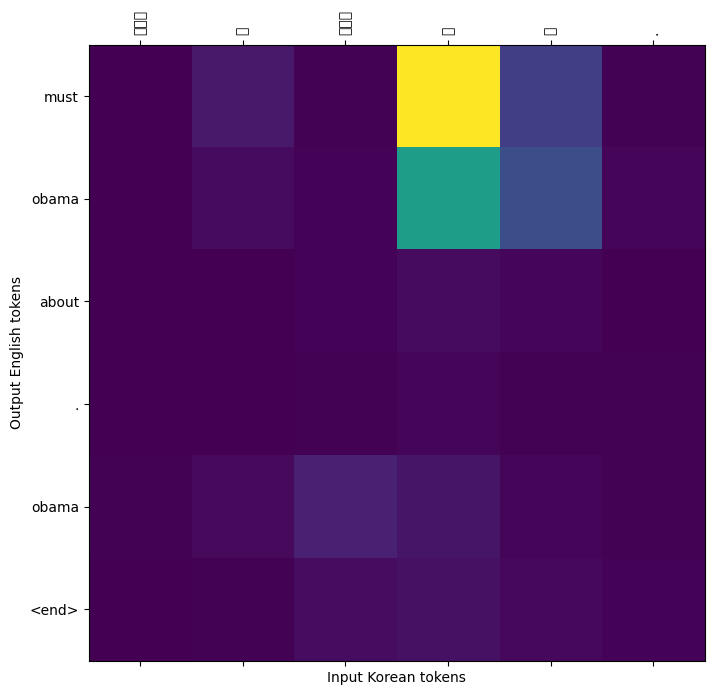

입력: 오바마는 대통령이다.
번역: must obama about . obama <end>


In [25]:
# ==============================
# 24. Attention Map 시각화
# ==============================
# 필수는 아니지만, Attention 기반 Seq2Seq 모델이므로
# Attention Map을 시각화하면 모델이 입력 문장의 어느 부분을 참고했는지 볼 수 있다.

def plot_attention(sentence, model):
    result, src_tokens, attentions = evaluate(sentence, model)
    output_tokens = result.split()

    if len(attentions) == 0:
        print("attention이 없습니다.")
        return

    # attention list를 하나의 행렬로 연결
    attention_matrix = np.concatenate(attentions, axis=0)

    # 실제 입력/출력 토큰 길이에 맞게 자르기
    attention_matrix = attention_matrix[:len(output_tokens),:len(src_tokens)]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.matshow(attention_matrix, cmap="viridis")

    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(output_tokens)))

    ax.set_xticklabels(src_tokens, rotation=90)
    ax.set_yticklabels(output_tokens)

    plt.xlabel("Input Korean tokens")
    plt.ylabel("Output English tokens")
    plt.show()

    print("입력:", sentence)
    print("번역:", result)

plot_attention("오바마는 대통령이다.", model)


In [26]:
# ==============================
# 25. 모델 저장
# ==============================
# 학습된 모델 파라미터를 저장합

torch.save(model.state_dict(),"kor_eng_seq2seq_attention_mecab.pth")

print("모델 저장 완료")


모델 저장 완료


# 디버깅 정리

데이터 정제 과정에서는 한국어와 영어의 병렬 쌍이 깨지지 않도록 주의했다.  
처음 데이터는 `.ko`, `.en` 파일로 따로 제공되지만, 같은 줄 번호끼리 번역 관계를 가진다.  
따라서 중복 제거를 할 때 한국어와 영어를 따로 처리하면 쌍이 어긋날 수 있다.  
이를 해결하기 위해 `zip(kor_raw, eng_raw)`으로 문장 쌍을 만든 뒤 `set()`으로 중복을 제거했다.

전처리 함수도 수정이 필요했다.  
기존 영어/스페인어용 전처리 함수는 한글을 고려하지 않으면 한국어 문자가 삭제될 수 있다.  
그래서 정규표현식에 `가-힣` 범위를 추가하여 한글이 유지되도록 했다.

학습과 추론의 토큰화 방식이 같아야 하므로, 학습 때 Mecab으로 나눈 한국어 문장을 번역 함수에서도 같은 방식으로 Mecab 토큰화했다.  
이 과정을 맞추지 않으면 모델이 학습한 입력 형태와 실제 번역할 때의 입력 형태가 달라져 번역 품질이 떨어질 수 있다.


# 회고

이번 프로젝트를 통해 번역 모델에서는 모델 구조뿐만 아니라 데이터 전처리와 토큰화가 매우 중요하다는 점을 알 수 있었다.  
특히 한국어는 영어처럼 단순히 공백 기준으로 단어가 잘 분리되지 않고, 조사와 어미가 붙어 있는 경우가 많다.  
그래서 Mecab과 같은 형태소 분석기를 사용하여 한국어 문장을 더 작은 의미 단위로 나누는 과정이 필요했다.

Seq2Seq 모델은 Encoder가 입력 문장을 읽고 Decoder가 출력 문장을 생성하는 구조이다.  
단순 Seq2Seq는 Encoder의 마지막 hidden state에 입력 문장 정보를 모두 담아야 하기 때문에 긴 문장에서는 정보 손실이 생길 수 있다.  
Attention을 사용하면 Decoder가 단어를 생성할 때 Encoder의 모든 출력 중 어느 부분을 더 참고할지 계산할 수 있어 번역 성능을 높일 수 있다.

다만 한영 번역 데이터는 난이도가 높고, 학습 시간이 충분하지 않으면 번역 결과가 어색하게 나올 수 있다.  
결과를 더 개선하기 위해서는 epoch 수 증가, embedding size와 hidden size 조정, dropout 추가, beam search 적용 등을 시도해볼 수 있다.
